# PHASE 5: Model Selection, Training & Validation
**Traceability**
- Issue ID: #5 Model Selection, Training & Validation

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (XGBoost & CV Strategy)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Classical Baselines)

## 1. Objectives
- **Reasoning**: We need a validation strategy that mimics deployment. Random splitting causes data leakage because samples from the same engine are highly correlated. We use **GroupKFold**.
- **Action**: Tune hyperparameters for the best model.
- **Evaluation**: Analyze residuals to ensure no systematic bias.

## 2. Model Strategy
- Linear Regression
- XGBoost
- Random Forest
- Support Vector Regression (SVR)
- Neural Network (ANN)
- **Evaluation**: Compare model performance using metrics like RMSE, MAE, and R².

##  Common Blocks 
Common Imports

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import pickle

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

Load Data + Common Setup

In [3]:
# 1. Setup paths and constants
PROCESSED_DIR = Path("../data/processed")
target_col, group_col, time_col = "RUL", "unit_number", "time_cycles"
MAX_RUL = 125

# 2. Load and Apply Piecewise RUL (Clipping)
if "trained_labeled" not in globals():
    trained_labeled = pd.read_csv(PROCESSED_DIR / "train_labeled.csv")
    test_labeled = pd.read_csv(PROCESSED_DIR / "test_labeled.csv")

# Limit the RUL values to MAX_RUL to reduce noise in early-life data
trained_labeled[target_col] = trained_labeled[target_col].clip(upper=MAX_RUL)
test_labeled[target_col] = test_labeled[target_col].clip(upper=MAX_RUL)

# 3. Define features (Excluding IDs and targets)
feature_cols = [c for c in trained_labeled.columns if c not in [group_col, target_col, "label", time_col]]

# 4. Prepare Training Data
# We drop NaNs in the target to ensure the model has clean labels to learn from
train_df = trained_labeled.dropna(subset=[target_col])
X_train = train_df[feature_cols]
y_train = train_df[target_col].to_numpy()
groups = train_df[group_col].to_numpy()

# 5. Prepare Test Data (Final Cycle Only)
# This selects only the 'Moment of Truth' for each engine unit
last_idx = test_labeled.dropna(subset=[time_col]).groupby(group_col)[time_col].idxmax()
X_test_last = test_labeled.loc[last_idx, feature_cols]
y_test_last = test_labeled.loc[last_idx, target_col].to_numpy()

# 6. Cross-Validation Setup
gkf = GroupKFold(n_splits=5)

A1) NASA Scoring Function

In [4]:
def nasa_scoring_function(y_true, y_pred):
    """
    Official NASA asymmetric scoring. 
    Penalizes over-estimation (late maintenance) much harder than under-estimation.
    """
    d = y_pred - y_true
    # Formula: d < 0 (early) -> exp(-d/13)-1 | d > 0 (late) -> exp(d/10)-1
    score = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(score)

A2) Regression Report Function

In [5]:
def regression_report(y_train, pred_train, y_test, pred_test, title="Model Evaluation"):
    """
    Enhanced report that compares Training vs. Test performance to detect overfitting.
    """
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    # helper to calculate metrics
    def get_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        nasa = nasa_scoring_function(y_true, y_pred) # Using function from your file [cite: 27-35]
        acc = np.mean(np.abs(y_true - y_pred) <= 10) * 100
        return [rmse, mae, r2, nasa, acc]

    train_stats = get_metrics(y_train, pred_train)
    test_stats = get_metrics(y_test, pred_test)

    print(f"\n{'='*20} {title} {'='*20}")
    print(f"{'Metric':<20} | {'Train Result':<15} | {'Test Result':<15}")
    print(f"{'-'*56}")
    
    metrics_names = ["RMSE", "MAE", "R2 Score", "NASA Score", "Accuracy (±10)"]
    
    for name, tr, te in zip(metrics_names, train_stats, test_stats):
        print(f"{name:<20} | {tr:<15.4f} | {te:<15.4f}")
    
    # Overfitting Warning Logic
    # If Train RMSE is significantly lower than Test RMSE, it's a red flag.
    if train_stats[0] < (test_stats[0] * 0.5):
        print(f"\n⚠️  WARNING: High potential for OVERFITTING detected!")
        print(f"   Train RMSE is {((test_stats[0]-train_stats[0])/test_stats[0])*100:.1f}% lower than Test RMSE.")
    
    return {
        "train": {"rmse": train_stats[0], "r2": train_stats[2], "nasa": train_stats[3]},
        "test": {"rmse": test_stats[0], "r2": test_stats[2], "nasa": test_stats[3]}
    }

A3) Alignment Check Function

In [6]:
def check_alignment(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(y_true, errors, alpha=0.5)
    plt.axhline(10, color='r', linestyle='--', label='Accuracy Threshold (10)')
    plt.title("Error Magnitude vs. Actual RUL")
    plt.xlabel("Actual RUL (Days/Cycles left)")
    plt.ylabel("Absolute Error")
    plt.legend()
    plt.show()

A4) Model Evaluation

In [7]:
# --- EVALUATION BLOCK ---
def plot_comparison(y_true, y_pred):
    plt.figure(figsize=(15, 6))
    
    # Ensure data is flat for plotting
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    indices = np.arange(len(y_true))
    
    # Plotting True RUL (Blue) and Predicted RUL (Red)
    plt.bar(indices, y_true, color='royalblue', label='True RUL', alpha=0.8)
    plt.bar(indices, y_pred, color='red', label='Predicted RUL', alpha=0.6, width=0.4)
    
    plt.xlabel("Engine Unit Index", fontsize=12)
    plt.ylabel("Remaining Useful Life (Cycles)", fontsize=12)
    plt.title("Actual vs Predicted RUL (Moment of Truth)", fontsize=14)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## MODEL

### Import the necessary libraries

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.parallel import Parallel, delayed

### Model setup

In [9]:
# Rigorous Model Setup
models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    
    "Decision Tree": make_pipeline(StandardScaler(), DecisionTreeRegressor(
        max_depth=5,             
        min_samples_leaf=20,     
        min_samples_split=50,    
        random_state=42
    )),
    
    "Random Forest": make_pipeline(StandardScaler(), RandomForestRegressor(
        n_estimators=500,       
        max_depth=20,           
        max_features=0.5,       
        min_samples_leaf=10,     
        n_jobs=-1, 
        random_state=42
    )),
    
    "XGBoost": make_pipeline(StandardScaler(), XGBRegressor(
        n_estimators=100,
        learning_rate=0.02,      # Slow down learning
        max_depth=3,             # Shallow trees are harder to overfit
        reg_lambda=10,           # L2 regularization
        alpha=1,                 # L1 regularization
        subsample=0.5,           # Use only 50% of data per tree to add randomness
        random_state=42
    )),
    
    "SVR": make_pipeline(StandardScaler(), SVR(
        kernel='rbf', C=20, epsilon=0.5, gamma='scale',max_iter=20000)),
    
    "Neural Network (ANN)": make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(32, 8), # Smaller layers are harder to overfit
        alpha=0.5,                   # L2 Penalty: Punishes the model for complex weights
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=1000,               # More iterations but slower learning
        early_stopping=True,         # Stop training if validation error stops improving
        validation_fraction=0.1, 
        random_state=42
    ))
}

# Define the scoring dictionary for Cross-Validation
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

### Training the models

In [ ]:
results_cv = {}

for name, model in models.items():
    print(f"Training and Cross-Validating {name}...")
    
    # 5-Fold GroupKFold Cross-Validation 
    cv_res = cross_validate(
        model, X_train, y_train, 
        groups=groups, cv=gkf, 
        scoring=scoring, n_jobs=-1
    )
    
    # Store CV results (flipping negative values back to positive)
    results_cv[name] = {
        "CV_RMSE": -cv_res["test_rmse"].mean(),
        "CV_MAE": -cv_res["test_mae"].mean(),
        "CV_R2": cv_res["test_r2"].mean()
    }
    
    # Final Fit on the full training set [cite: 17, 18]
    model.fit(X_train, y_train)

Training and Cross-Validating Linear Regression...
Training and Cross-Validating Decision Tree...
Training and Cross-Validating Random Forest...
Training and Cross-Validating XGBoost...
Training and Cross-Validating SVR...


d:\ml\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=20000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training and Cross-Validating Neural Network (ANN)...


### Evaluation Block (Test Data & Visualization)


==================== Linear Regression Analysis ====================
Metric               | Train Result    | Test Result    
--------------------------------------------------------
RMSE                 | 12.8235         | 33.5946        
MAE                  | 10.1656         | 26.9687        
R2 Score             | 0.9053          | 0.2972         
NASA Score           | 95580.7474      | 2057.2580      
Accuracy (±10)       | 56.5044         | 39.0000        

⚠️  WARNING: High potential for OVERFITTING detected!
   Train RMSE is 61.8% lower than Test RMSE.


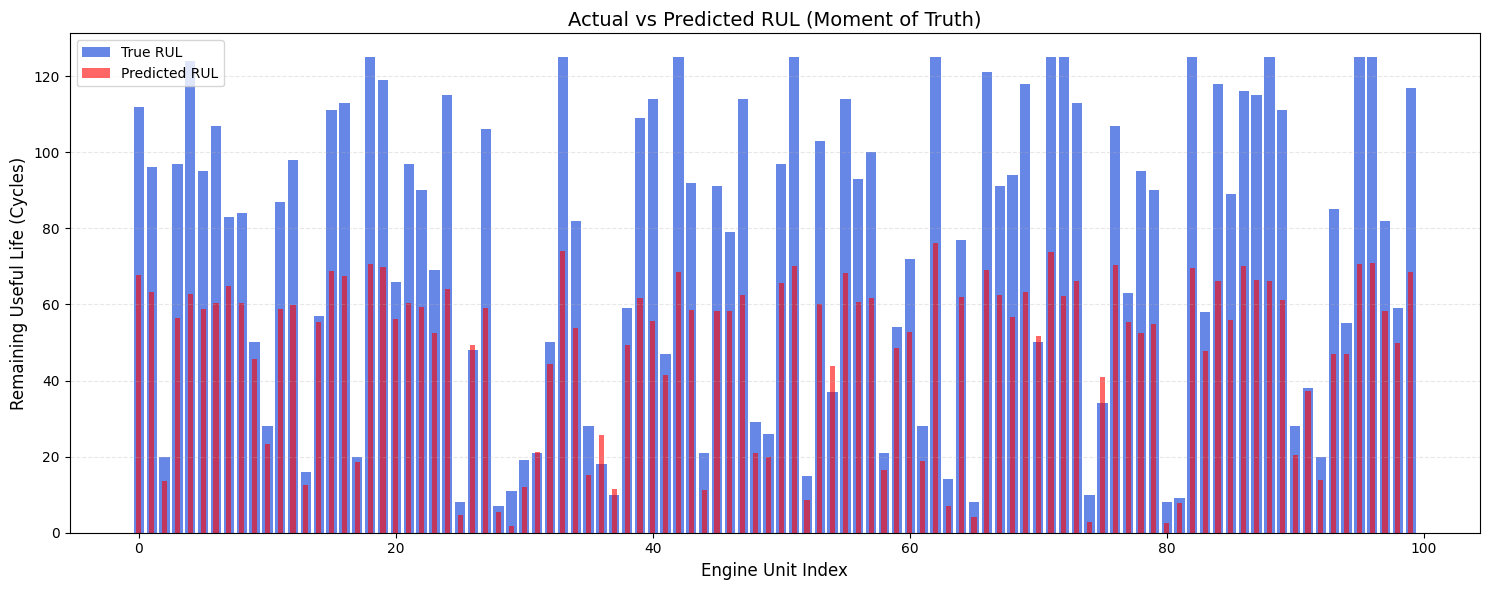

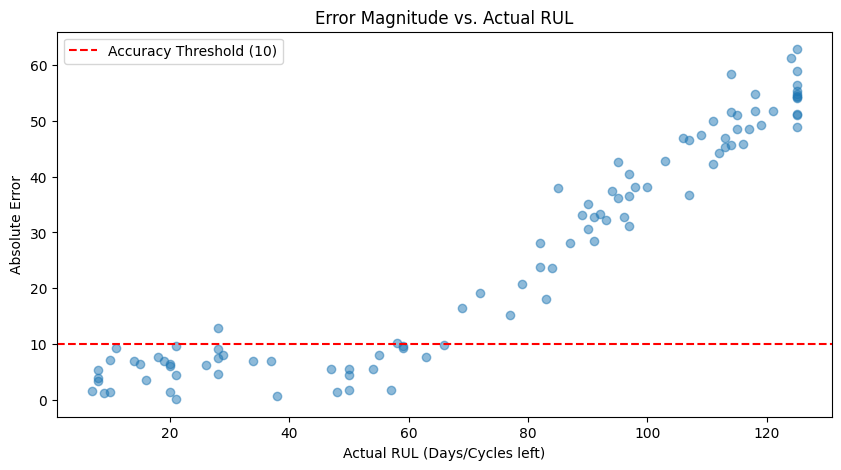


==================== Decision Tree Analysis ====================
Metric               | Train Result    | Test Result    
--------------------------------------------------------
RMSE                 | 0.9715          | 1.1576         
MAE                  | 0.6356          | 0.8900         
R2 Score             | 0.9995          | 0.9992         
NASA Score           | 2480.6746       | 8.4382         
Accuracy (±10)       | 100.0000        | 100.0000       


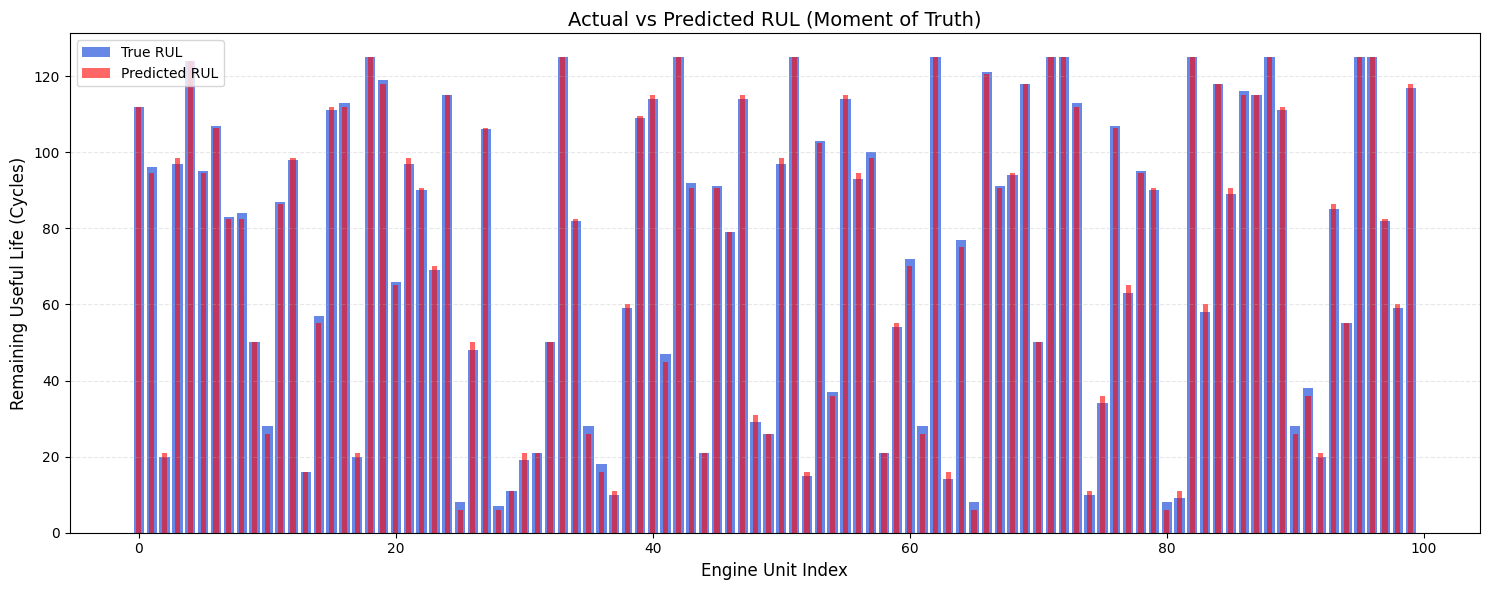

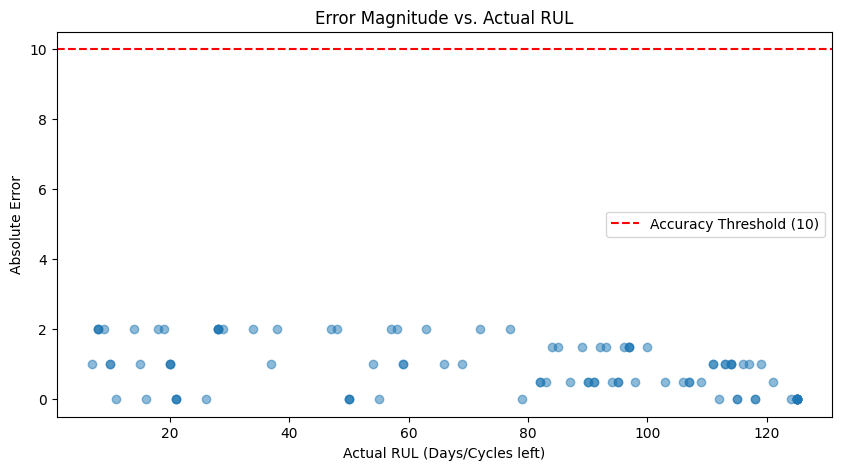


==================== Random Forest Analysis ====================
Metric               | Train Result    | Test Result    
--------------------------------------------------------
RMSE                 | 0.1083          | 5.3597         
MAE                  | 0.0550          | 4.1607         
R2 Score             | 1.0000          | 0.9821         
NASA Score           | 202.0298        | 42.7644        
Accuracy (±10)       | 100.0000        | 89.0000        

⚠️  WARNING: High potential for OVERFITTING detected!
   Train RMSE is 98.0% lower than Test RMSE.


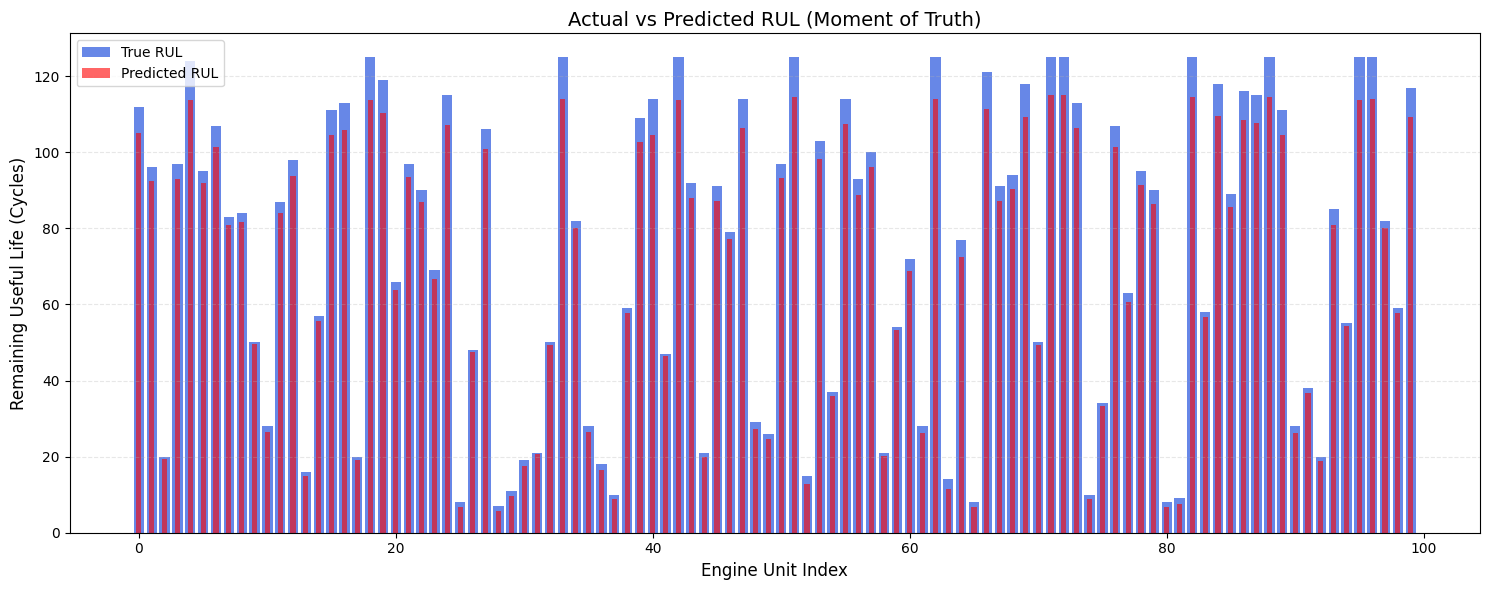

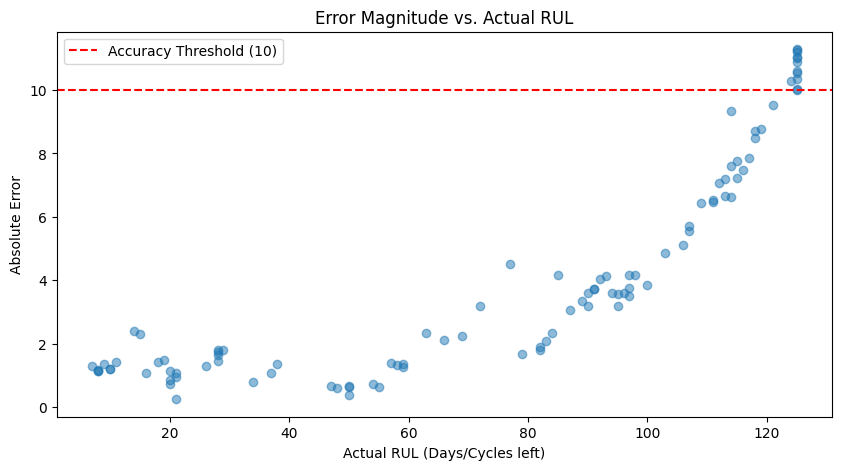


==================== XGBoost Analysis ====================
Metric               | Train Result    | Test Result    
--------------------------------------------------------
RMSE                 | 5.7075          | 5.6098         
MAE                  | 5.0012          | 4.6657         
R2 Score             | 0.9812          | 0.9804         
NASA Score           | 25952.6200      | 62.6772        
Accuracy (±10)       | 93.6921         | 92.0000        


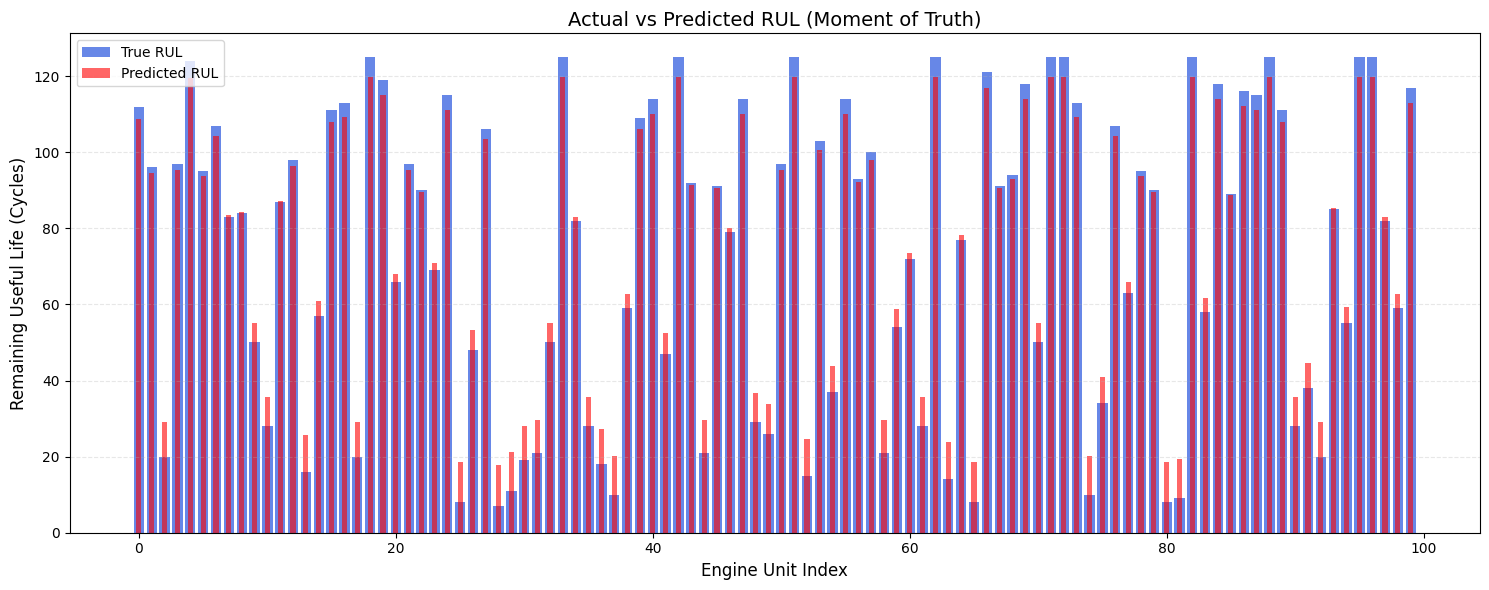

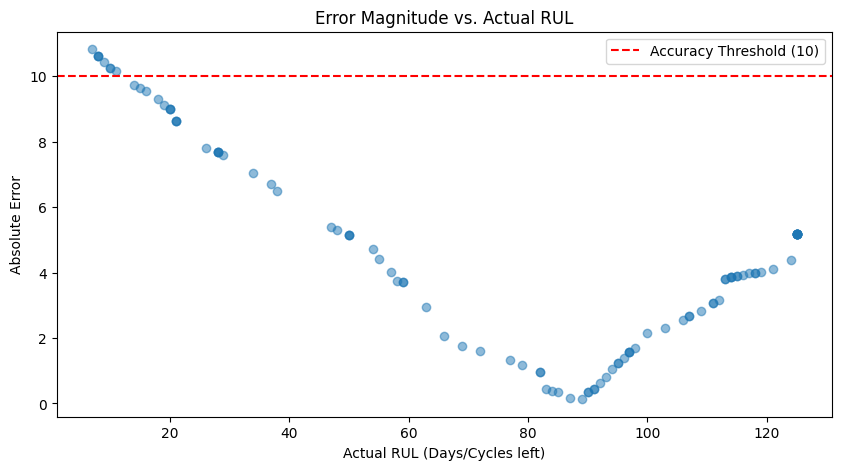


==================== SVR Analysis ====================
Metric               | Train Result    | Test Result    
--------------------------------------------------------
RMSE                 | 2.4989          | 11.9687        
MAE                  | 1.7508          | 9.9854         
R2 Score             | 0.9964          | 0.9108         
NASA Score           | 7513.2481       | 163.9083       
Accuracy (±10)       | 99.4493         | 55.0000        

⚠️  WARNING: High potential for OVERFITTING detected!
   Train RMSE is 79.1% lower than Test RMSE.


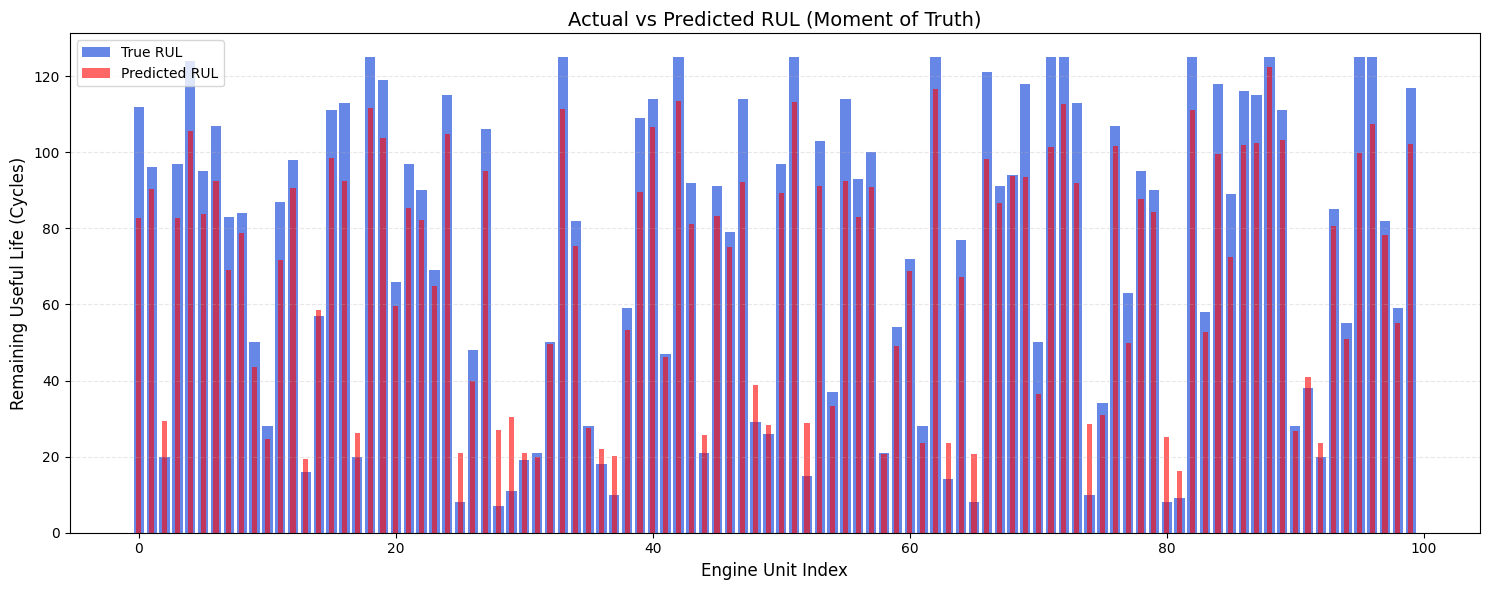

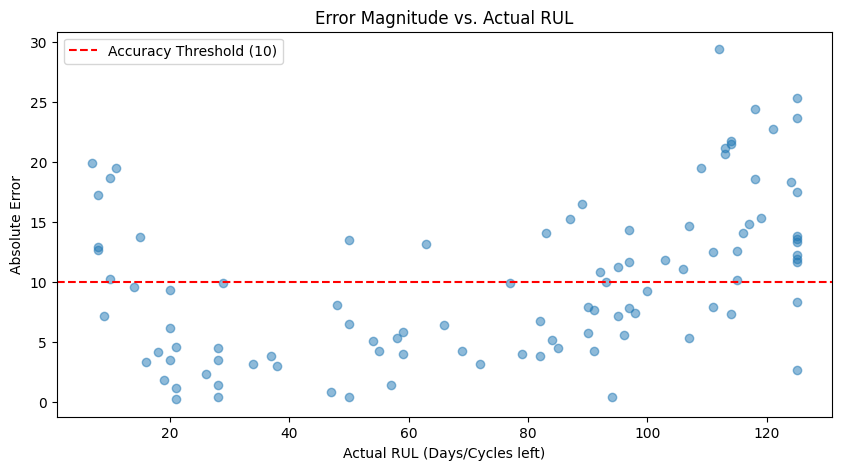


==================== Neural Network (ANN) Analysis ====================
Metric               | Train Result    | Test Result    
--------------------------------------------------------
RMSE                 | 0.9809          | 1.6729         
MAE                  | 0.4415          | 1.1046         
R2 Score             | 0.9994          | 0.9983         
NASA Score           | 1742.9627       | 12.3475        
Accuracy (±10)       | 100.0000        | 100.0000       


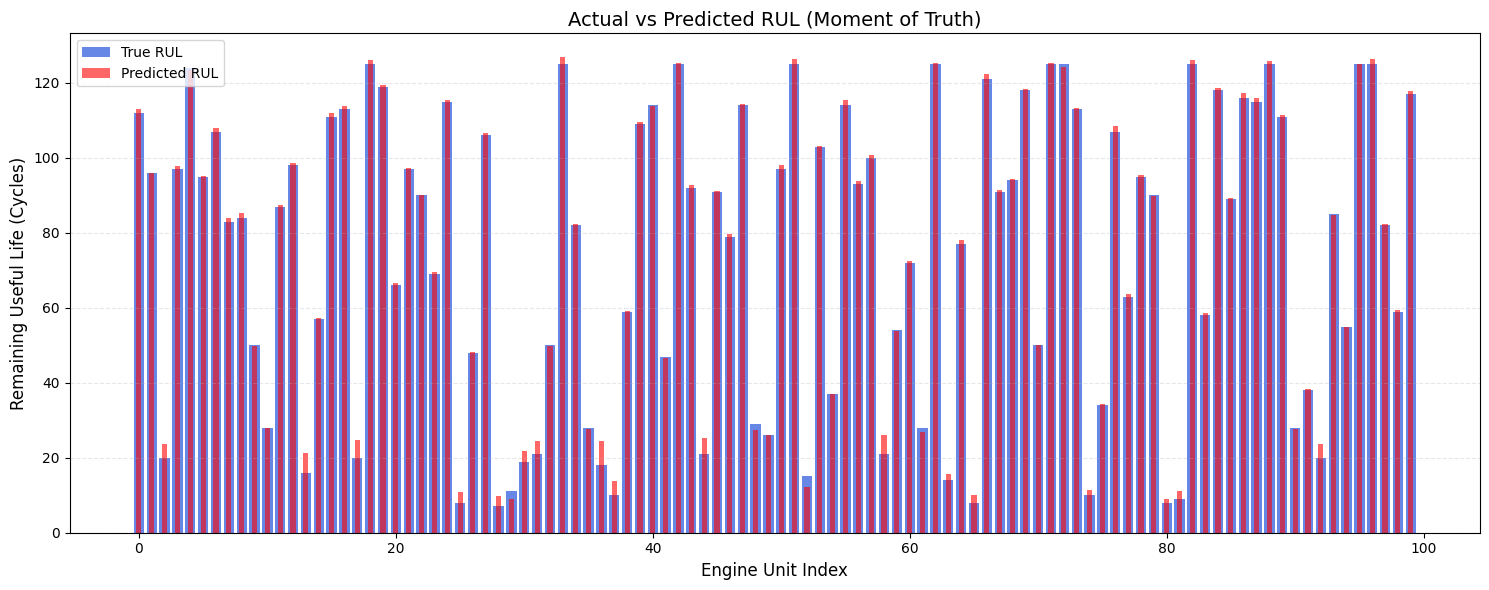

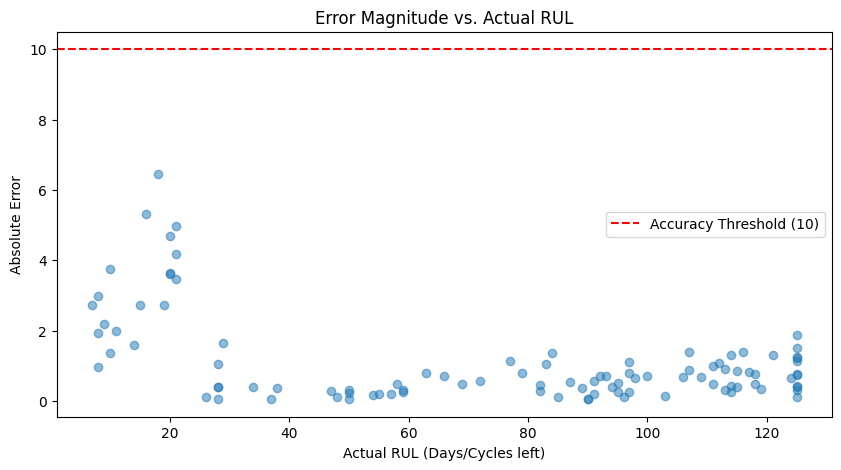

In [13]:
for name, model in models.items():
    # Predict on the final cycle of test engines [cite: 23]
    y_pred_test = model.predict(X_test_last)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test_last)
    # Generate the rigorous report from your file [cite: 36-50]
    regression_report(y_train, train_preds, y_test_last, test_preds, title=f"{name} Analysis")
    
    # Visualization using your comparison plot [cite: 62-77]
    plot_comparison(y_test_last, y_pred_test)
    
    # Safety Check: Error vs Actual RUL [cite: 51-60]
    check_alignment(y_test_last, y_pred_test)